# Classification ML — Prototype hors app

Objectif : trouver une formulation du problème ML qui donne des scores **non-triviaux mais significatifs** (AUC entre 0.75 et 0.95).

**Approche choisie — Option 2 : labels comportementaux multi-classes**
- Les labels sont construits par **règles métier** sur les features brutes (pas les features RF)
- Le RF apprend ensuite à prédire ces labels depuis les **features agrégées comportementales**
- Séparation explicite entre features de labeling et features de classification

**4 classes :**
- `Normal` : comportement standard
- `Scanner` : haute diversité de ports ciblés (port scanning)
- `Flood` : volume élevé + nombreuses destinations (DDoS/flood)
- `Brute-Force` : connexions concentrées sur ports auth, majoritairement DENY

In [16]:
import sys
from pathlib import Path

# Ajouter src/ au path pour accéder aux modules du projet
PROJECT_ROOT = Path("../src").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, RocCurveDisplay
)

plt.style.use("dark_background")
PALETTE = {"Normal": "#00ff9d", "Scanner": "#00d4ff", "Flood": "#ff3c6e", "Brute-Force": "#a259ff"}

print("Imports OK")

Imports OK


## 1. Chargement des données

In [17]:
DATA_ORIGINAL  = PROJECT_ROOT / "data" / "original_data.parquet"
DATA_GENERATED = PROJECT_ROOT / "data" / "processed" / "generated_data.csv"

df_orig = pd.read_parquet(DATA_ORIGINAL)
df_gen  = pd.read_csv(DATA_GENERATED)

print(f"original_data  : {len(df_orig):,} lignes — colonnes : {list(df_orig.columns)}")
print(f"generated_data : {len(df_gen):,} lignes — colonnes : {list(df_gen.columns)}")

original_data  : 4,572,903 lignes — colonnes : ['datetime', 'action', 'rule_id', 'interface_in', 'interface_out', 'ip_src', 'ip_dst', 'protocol', 'port_src', 'port_dst']
generated_data : 15,906 lignes — colonnes : ['datetime', 'ip_src', 'ip_dst', 'port_dst', 'proto', 'action', 'rule_id', 'interface']


## 2. Normalisation des colonnes

`original_data` a `proto` et `interface` ; `generated_data` a `protocol`, `interface_in`, `interface_out`.
On harmonise pour avoir les mêmes colonnes dans les deux cas.

In [18]:
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # original_data : proto -> protocol
    if "proto" in df.columns and "protocol" not in df.columns:
        df = df.rename(columns={"proto": "protocol"})
    # original_data : interface -> interface_in
    if "interface" in df.columns and "interface_in" not in df.columns:
        df = df.rename(columns={"interface": "interface_in"})
    # Assurer que datetime est parsé
    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    return df

df_orig = normalize_columns(df_orig)
df_gen  = normalize_columns(df_gen)

print("Colonnes orig :", list(df_orig.columns))
print("Colonnes gen  :", list(df_gen.columns))

Colonnes orig : ['datetime', 'action', 'rule_id', 'interface_in', 'interface_out', 'ip_src', 'ip_dst', 'protocol', 'port_src', 'port_dst']
Colonnes gen  : ['datetime', 'ip_src', 'ip_dst', 'port_dst', 'protocol', 'action', 'rule_id', 'interface_in']


## 3. Feature engineering — agrégation par IP source

**Features comportementales (pour le RF) :**

| Feature | Description |
|---------|-------------|
| `nb_connexions` | Volume total de connexions |
| `nb_ports_distincts` | Diversité des ports ciblés |
| `nb_ips_dst` | Nombre de destinations uniques |
| `ratio_deny` | Proportion de connexions bloquées |
| `nb_ports_sensibles` | Connexions vers ports auth (21,22,23,3306,3389) |
| `activite_nuit` | Part de l'activité entre 0h et 6h |
| `port_dst_std` | Écart-type des ports de destination |
| `entropy_ports` | Entropie de Shannon des ports (diversité normalisée) |

In [19]:
from scipy.stats import entropy as scipy_entropy

SENSITIVE_PORTS = {21, 22, 23, 3306, 3389, 445, 139, 1433}

def compute_ip_features(df: pd.DataFrame) -> pd.DataFrame:
    """Agrege les logs firewall par IP source -> vecteur comportemental."""
    dw = df.copy()
    if "datetime" in dw.columns:
        dw["datetime"] = pd.to_datetime(dw["datetime"], errors="coerce")
        dw["hour"] = dw["datetime"].dt.hour
    else:
        dw["hour"] = 12

    def port_entropy(ports):
        counts = ports.value_counts(normalize=True)
        return float(scipy_entropy(counts))

    def top_port_ratio(ports):
        """Part du port le plus frequent parmi toutes les connexions."""
        if len(ports) == 0:
            return 0.0
        return float(ports.value_counts(normalize=True).iloc[0])

    ipf = (
        dw.groupby("ip_src")
        .agg(
            nb_connexions      = ("ip_src",   "count"),
            nb_ports_distincts = ("port_dst",  "nunique"),
            nb_ips_dst         = ("ip_dst",    "nunique"),
            ratio_deny         = ("action",    lambda x: (x == "DENY").mean()),
            nb_ports_sensibles = ("port_dst",  lambda x: x.isin(SENSITIVE_PORTS).sum()),
            activite_nuit      = ("hour",      lambda x: ((x >= 0) & (x < 6)).mean()),
            port_dst_std       = ("port_dst",  "std"),
            entropy_ports      = ("port_dst",  port_entropy),
            top_port_ratio     = ("port_dst",  top_port_ratio),
        )
        .reset_index()
    )
    ipf["port_dst_std"] = ipf["port_dst_std"].fillna(0)
    ipf["ratio_sensible"] = ipf["nb_ports_sensibles"] / ipf["nb_connexions"].clip(lower=1)
    return ipf


ipf_orig = compute_ip_features(df_orig)
ipf_gen  = compute_ip_features(df_gen)

print(f"original_data  -> {len(ipf_orig):,} IPs uniques")
print(f"generated_data -> {len(ipf_gen):,} IPs uniques")
ipf_orig.describe()


original_data  -> 130,849 IPs uniques
generated_data -> 50 IPs uniques


,nb_connexions,nb_ports_distincts,nb_ips_dst,ratio_deny,nb_ports_sensibles,activite_nuit,port_dst_std,entropy_ports,top_port_ratio,ratio_sensible
count,130849.000000,130849.000000,130849.0,130849.000000,130849.000000,130849.000000,130849.000000,130849.000000,130849.000000,130849.000000
mean,34.947940,5.801198,1.0,0.322473,1.167177,0.345738,808.118255,0.199601,0.924862,0.231211
std,3576.222935,356.016818,0.0,0.462686,8.739388,0.406798,3576.364101,0.690027,0.218755,0.416992
min,1.000000,1.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000020,0.000000
25%,1.000000,1.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,2.000000,1.000000,1.0,0.000000,0.000000,0.142857,0.000000,0.000000,1.000000,0.000000
75%,11.000000,1.000000,1.0,1.000000,0.000000,0.675676,0.000000,0.000000,1.000000,0.000000
max,773605.000000,64415.000000,1.0,1.000000,930.000000,1.000000,46021.337747,11.047318,1.000000,1.000000


## 4. Labeling comportemental

**Separation stricte features de labeling / features RF :**

| Label | Regle | Features de labeling |
|-------|-------|----------------------|
| **Scanner** | `nb_ports_distincts > q75` | `nb_ports_distincts` |
| **Brute-Force** | `nb_ports_sensibles >= 5` | `nb_ports_sensibles` |
| **Flood** | `nb_connexions > q95 AND nb_ips_dst > mediane` | `nb_connexions`, `nb_ips_dst` |
| **Normal** | tout le reste | — |

**Features RF** : `ratio_deny`, `activite_nuit`, `port_dst_std`, `entropy_ports`, `top_port_ratio`


In [20]:
def assign_behavioral_labels(ipf: pd.DataFrame) -> pd.DataFrame:
    """
    Assigne un label comportemental a chaque IP.
    Priorite : Scanner > Brute-Force > Flood > Normal
    """
    ipf = ipf.copy()

    q95_connexions      = ipf["nb_connexions"].quantile(0.95)
    q75_ports_distincts = ipf["nb_ports_distincts"].quantile(0.75)
    median_ips_dst      = ipf["nb_ips_dst"].median()

    print(f"  Seuil Scanner  (nb_ports_distincts > {q75_ports_distincts:.0f})")
    print(f"  Seuil BF       (nb_ports_sensibles >= 5)")
    print(f"  Seuil Flood    (nb_connexions > {q95_connexions:.0f} AND nb_ips_dst > {median_ips_dst:.0f})")

    def label(row):
        if row["nb_ports_distincts"] > q75_ports_distincts:
            return "Scanner"
        elif row["nb_ports_sensibles"] >= 5:
            return "Brute-Force"
        elif row["nb_connexions"] > q95_connexions and row["nb_ips_dst"] > median_ips_dst:
            return "Flood"
        else:
            return "Normal"

    ipf["label"] = ipf.apply(label, axis=1)
    return ipf


print("=== original_data ===")
ipf_orig = assign_behavioral_labels(ipf_orig)
print(ipf_orig["label"].value_counts())

print("=== generated_data ===")
ipf_gen = assign_behavioral_labels(ipf_gen)
print(ipf_gen["label"].value_counts())


=== original_data ===
  Seuil Scanner  (nb_ports_distincts > 1)
  Seuil BF       (nb_ports_sensibles >= 5)
  Seuil Flood    (nb_connexions > 53 AND nb_ips_dst > 1)
label
Normal         110713
Scanner         17352
Brute-Force      2784
Name: count, dtype: int64
=== generated_data ===
  Seuil Scanner  (nb_ports_distincts > 10)
  Seuil BF       (nb_ports_sensibles >= 5)
  Seuil Flood    (nb_connexions > 1165 AND nb_ips_dst > 1)
label
Normal         32
Scanner        12
Brute-Force     5
Flood           1
Name: count, dtype: int64


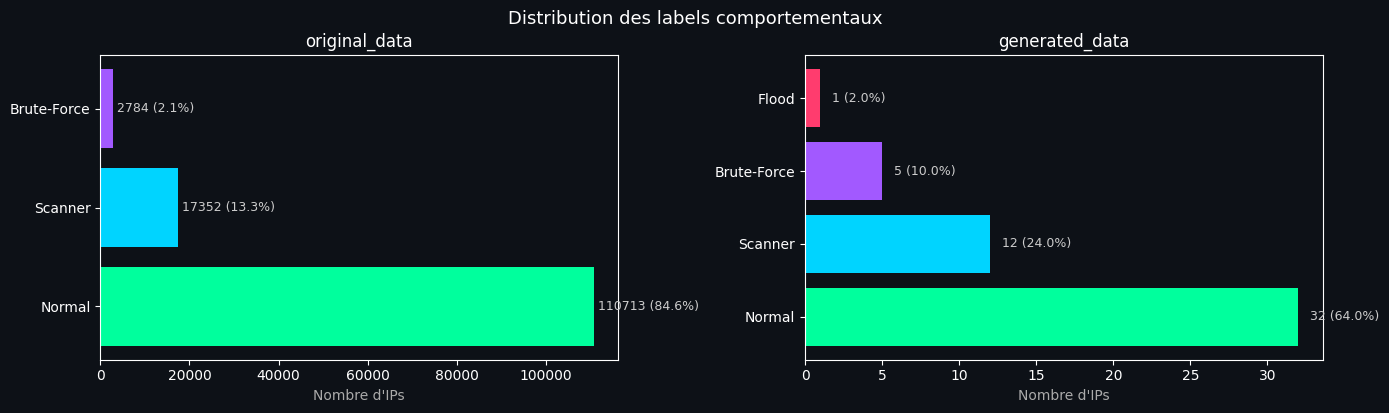

In [21]:
# Visualisation de la distribution des labels
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (ipf, title) in zip(axes, [(ipf_orig, "original_data"), (ipf_gen, "generated_data")]):
    counts = ipf["label"].value_counts()
    colors = [PALETTE.get(c, "#888") for c in counts.index]
    ax.barh(counts.index, counts.values, color=colors)
    ax.set_title(title, color="white", fontsize=12)
    ax.set_xlabel("Nombre d'IPs", color="#aaa")
    for i, (idx, val) in enumerate(counts.items()):
        ax.text(val + 0.5, i, f" {val} ({val/len(ipf)*100:.1f}%)", va="center", color="#ccc", fontsize=9)
    ax.tick_params(colors="white")
    ax.set_facecolor("#0d1117")

fig.patch.set_facecolor("#0d1117")
plt.tight_layout()
plt.suptitle("Distribution des labels comportementaux", color="white", y=1.02, fontsize=13)
plt.show()

## 5. Vérification de la séparation features / labels

Analyse de corrélation pour s'assurer que le RF ne peut pas juste "réapprendre" les règles de labeling.

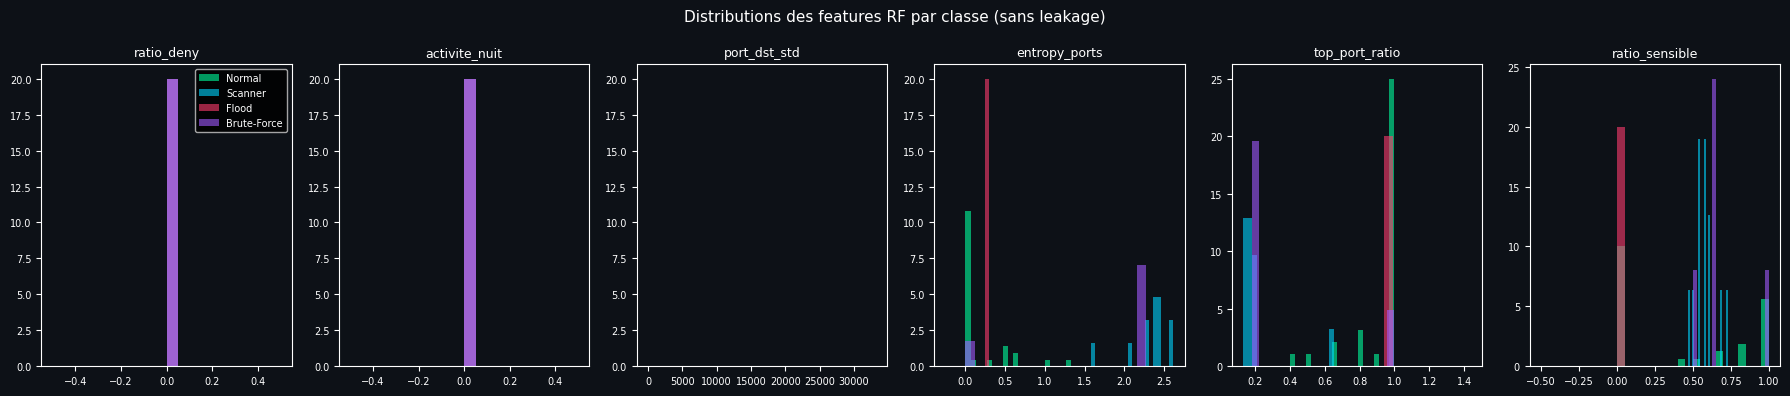

In [25]:
# Features RF : strictement separees des features de labeling.
#
# Features de LABELING (exclues du RF) :
#   nb_ports_distincts -> Scanner
#   nb_ports_sensibles, nb_connexions -> Brute-Force
#   nb_connexions, nb_ips_dst -> Flood
#
# Features RF propres :
FEATURES = [
    "ratio_deny",       # proportion connexions bloquees
    "activite_nuit",    # part activite 0h-6h
    "port_dst_std",     # dispersion des ports cibles
    "entropy_ports",    # diversite normalisee (Shannon)
    "top_port_ratio",   # concentration sur le port le plus frequent (signal BF)
    "ratio_sensible",   # proportion du trafic vers ports auth (signal BF fort)
]

# Distributions par classe
fig, axes = plt.subplots(1, len(FEATURES), figsize=(len(FEATURES)*3, 4))
for i, feat in enumerate(FEATURES):
    ax = axes[i]
    for label_name, color in PALETTE.items():
        sub = ipf_gen[ipf_gen["label"] == label_name][feat]
        if len(sub) > 0:
            ax.hist(sub, bins=20, alpha=0.6, color=color, label=label_name, density=True)
    ax.set_title(feat, color="white", fontsize=9)
    ax.set_facecolor("#0d1117")
    ax.tick_params(colors="white", labelsize=7)
    if i == 0:
        ax.legend(fontsize=7)

fig.patch.set_facecolor("#0d1117")
plt.suptitle("Distributions des features RF par classe (sans leakage)", color="white", fontsize=11)
plt.tight_layout()
plt.show()


## 6. Entraînement Random Forest

Paramètres à tester :
- `max_depth` : 4, 6, 8 → contrôle la complexité (évite la mémorisation parfaite)
- Métrique CV : `roc_auc_ovr_weighted` (multi-classe)

BF weight= 4 | precision=0.44  recall=0.83  f1=0.58
BF weight= 6 | precision=0.37  recall=0.90  f1=0.52
BF weight= 8 | precision=0.37  recall=0.90  f1=0.52
BF weight=10 | precision=0.37  recall=0.90  f1=0.52
BF weight=12 | precision=0.37  recall=0.90  f1=0.52
BF weight=16 | precision=0.37  recall=0.90  f1=0.52
BF weight=20 | precision=0.37  recall=0.90  f1=0.52


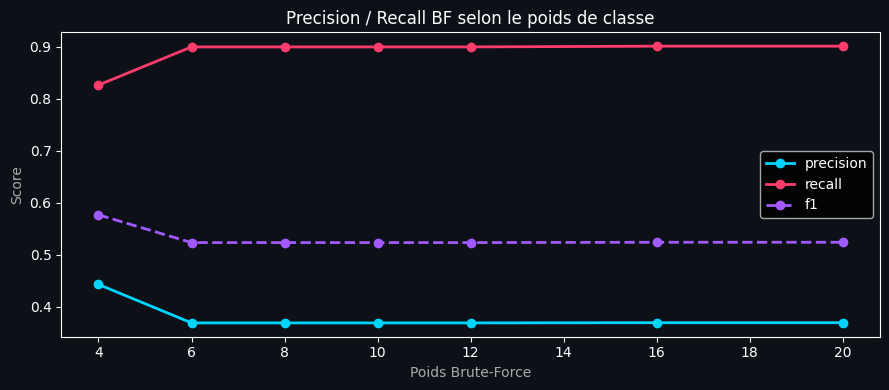

In [33]:
# Recherche du meilleur poids pour Brute-Force
from sklearn.metrics import precision_score, recall_score, f1_score

bf_weights = [4, 6, 8, 10, 12, 16, 20]
results_w = []

X = ipf_orig[FEATURES]
y = ipf_orig["label"]
counts = y.value_counts()
valid = counts[counts >= 5].index
X, y = X[y.isin(valid)], y[y.isin(valid)]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

for w in bf_weights:
    cw = {"Normal": 1, "Scanner": 2, "Brute-Force": w, "Flood": w}
    rf = RandomForestClassifier(
        n_estimators=100, max_depth=6, min_samples_leaf=3,
        class_weight=cw, random_state=42, n_jobs=-1
    )
    rf.fit(X_tr, y_tr)
    y_pred = rf.predict(X_te)
    p = precision_score(y_te, y_pred, labels=["Brute-Force"], average=None, zero_division=0)[0]
    r = recall_score(y_te, y_pred, labels=["Brute-Force"], average=None, zero_division=0)[0]
    f1 = f1_score(y_te, y_pred, labels=["Brute-Force"], average=None, zero_division=0)[0]
    results_w.append((w, p, r, f1))
    print(f"BF weight={w:2d} | precision={p:.2f}  recall={r:.2f}  f1={f1:.2f}")

# Visualisation
fig, ax = plt.subplots(figsize=(9, 4))
ws = [r[0] for r in results_w]
ax.plot(ws, [r[1] for r in results_w], marker="o", color="#00d4ff", label="precision", lw=2)
ax.plot(ws, [r[2] for r in results_w], marker="o", color="#ff3c6e", label="recall", lw=2)
ax.plot(ws, [r[3] for r in results_w], marker="o", color="#a259ff", label="f1", lw=2, linestyle="--")
ax.set_xlabel("Poids Brute-Force", color="#aaa")
ax.set_ylabel("Score", color="#aaa")
ax.set_title("Precision / Recall BF selon le poids de classe", color="white")
ax.legend()
ax.set_facecolor("#0d1117")
ax.tick_params(colors="white")
fig.patch.set_facecolor("#0d1117")
plt.tight_layout()
plt.show()


In [34]:
def train_and_evaluate(ipf: pd.DataFrame, dataset_name: str, max_depth: int = 6):
    """Entraîne un RF et retourne les métriques."""
    X = ipf[FEATURES]
    y = ipf["label"]

    # Filtrer les classes avec trop peu d'exemples
    counts = y.value_counts()
    valid = counts[counts >= 5].index
    mask = y.isin(valid)
    X, y = X[mask], y[mask]
    
    if y.nunique() < 2:
        print(f"[{dataset_name}] Pas assez de classes — skip")
        return None

    print(f"\n{'='*60}")
    print(f"Dataset: {dataset_name} | max_depth={max_depth} | {len(X)} IPs | {y.nunique()} classes")
    print(f"Distribution: {dict(y.value_counts())}")

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=max_depth,
        min_samples_leaf=3,
        class_weight={"Normal": 1, "Scanner": 2, "Brute-Force": 4, "Flood": 4},
        random_state=42,
        n_jobs=-1,
    )
    rf.fit(X_tr, y_tr)
    y_pred = rf.predict(X_te)

    # CV
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(rf, X, y, cv=skf, scoring="roc_auc_ovr_weighted", n_jobs=-1)
    
    print(f"\n--- Classification Report ---")
    print(classification_report(y_te, y_pred))
    print(f"ROC-AUC OVR CV 5-fold : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    return {
        "rf": rf, "X_te": X_te, "y_te": y_te, "y_pred": y_pred,
        "classes": rf.classes_, "cv": cv_scores,
        "imp_df": pd.DataFrame({"feature": FEATURES, "importance": rf.feature_importances_}).sort_values("importance", ascending=False),
        "cm": confusion_matrix(y_te, y_pred, labels=rf.classes_),
        "dataset": dataset_name,
    }


res_orig = train_and_evaluate(ipf_orig, "original_data", max_depth=6)
res_gen  = train_and_evaluate(ipf_gen,  "generated_data", max_depth=6)


Dataset: original_data | max_depth=6 | 130849 IPs | 3 classes
Distribution: {'Normal': 110713, 'Scanner': 17352, 'Brute-Force': 2784}

--- Classification Report ---
              precision    recall  f1-score   support

 Brute-Force       0.44      0.83      0.58       696
      Normal       1.00      0.97      0.98     27679
     Scanner       1.00      1.00      1.00      4338

    accuracy                           0.97     32713
   macro avg       0.81      0.93      0.85     32713
weighted avg       0.98      0.97      0.98     32713

ROC-AUC OVR CV 5-fold : 0.9971 ± 0.0003

Dataset: generated_data | max_depth=6 | 49 IPs | 3 classes
Distribution: {'Normal': 32, 'Scanner': 12, 'Brute-Force': 5}

--- Classification Report ---
              precision    recall  f1-score   support

 Brute-Force       0.00      0.00      0.00         1
      Normal       0.82      1.00      0.90         9
     Scanner       1.00      0.67      0.80         3

    accuracy                           0.8

c:\Users\ychen\Documents\GitHub\SISE_OPSISE\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ychen\Documents\GitHub\SISE_OPSISE\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ychen\Documents\GitHub\SISE_OPSISE\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

## 7. Courbes ROC multi-classes (One-vs-Rest)

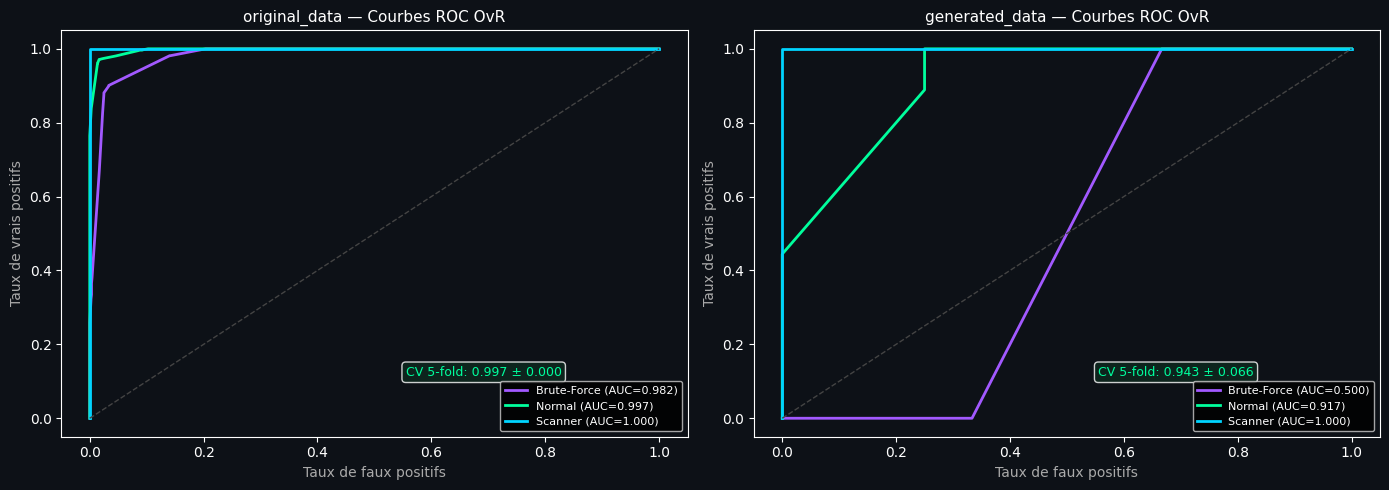

In [28]:
def plot_roc_curves(result, ax, title):
    if result is None:
        return
    classes = result["classes"]
    X_te, y_te = result["X_te"], result["y_te"]
    rf = result["rf"]
    y_proba = rf.predict_proba(X_te)
    y_bin = label_binarize(y_te, classes=classes)

    for i, cls in enumerate(classes):
        if y_bin.shape[1] == 1:
            continue
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        color = PALETTE.get(cls, "#888")
        ax.plot(fpr, tpr, color=color, lw=2, label=f"{cls} (AUC={roc_auc:.3f})")

    ax.plot([0, 1], [0, 1], "--", color="#444", lw=1)
    ax.set_xlabel("Taux de faux positifs", color="#aaa")
    ax.set_ylabel("Taux de vrais positifs", color="#aaa")
    ax.set_title(title, color="white", fontsize=11)
    ax.legend(fontsize=8)
    ax.set_facecolor("#0d1117")
    ax.tick_params(colors="white")
    cv_mean = result["cv"].mean()
    cv_std  = result["cv"].std()
    ax.text(0.55, 0.15, f"CV 5-fold: {cv_mean:.3f} ± {cv_std:.3f}",
            transform=ax.transAxes, color="#00ff9d", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="#0d2a1f", alpha=0.8))


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_roc_curves(res_orig, axes[0], "original_data — Courbes ROC OvR")
plot_roc_curves(res_gen,  axes[1], "generated_data — Courbes ROC OvR")
fig.patch.set_facecolor("#0d1117")
plt.tight_layout()
plt.show()

## 8. Matrices de confusion

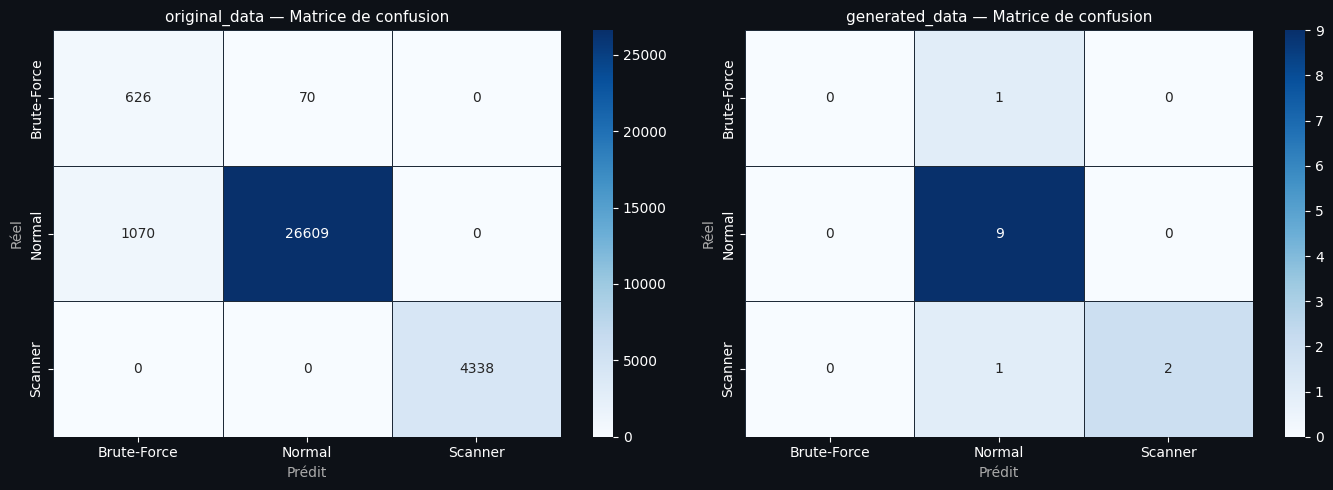

In [29]:
def plot_confusion_matrix(result, ax, title):
    if result is None:
        return
    cm = result["cm"]
    classes = result["classes"]
    cmap = sns.color_palette(["#0d1117", "#1e3a5f", "#00d4ff"], as_cmap=True)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=classes, yticklabels=classes,
        ax=ax, linewidths=0.5, linecolor="#1e2a38"
    )
    ax.set_title(title, color="white", fontsize=11)
    ax.set_xlabel("Prédit", color="#aaa")
    ax.set_ylabel("Réel", color="#aaa")
    ax.tick_params(colors="white")
    ax.set_facecolor("#0d1117")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_confusion_matrix(res_orig, axes[0], "original_data — Matrice de confusion")
plot_confusion_matrix(res_gen,  axes[1], "generated_data — Matrice de confusion")
fig.patch.set_facecolor("#0d1117")
plt.tight_layout()
plt.show()

## 9. Importance des features

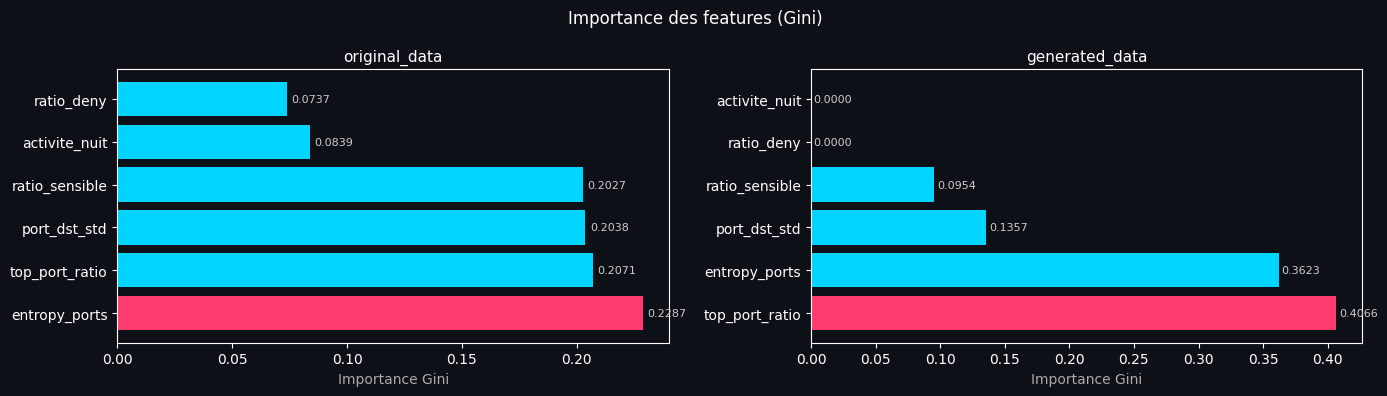

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, result in zip(axes, [res_orig, res_gen]):
    if result is None:
        continue
    imp = result["imp_df"]
    colors = ["#ff3c6e" if i == 0 else "#00d4ff" for i in range(len(imp))]
    ax.barh(imp["feature"], imp["importance"], color=colors)
    ax.set_title(result["dataset"], color="white", fontsize=11)
    ax.set_xlabel("Importance Gini", color="#aaa")
    ax.set_facecolor("#0d1117")
    ax.tick_params(colors="white")
    for j, (feat, imp_val) in enumerate(zip(imp["feature"], imp["importance"])):
        ax.text(imp_val + 0.002, j, f"{imp_val:.4f}", va="center", color="#ccc", fontsize=8)

fig.patch.set_facecolor("#0d1117")
plt.suptitle("Importance des features (Gini)", color="white", fontsize=12)
plt.tight_layout()
plt.show()

## 10. Exploration des seuils — sensibilité au max_depth

Testons différentes profondeurs pour trouver le bon compromis biais/variance.

dataset    generated  original
max_depth                     
NaN         0.943492  0.997382
3.0         0.950992  0.996152
4.0         0.943492  0.996134
5.0         0.943492  0.996595
6.0         0.943492  0.997041
8.0         0.943492  0.997275
10.0        0.943492  0.997372


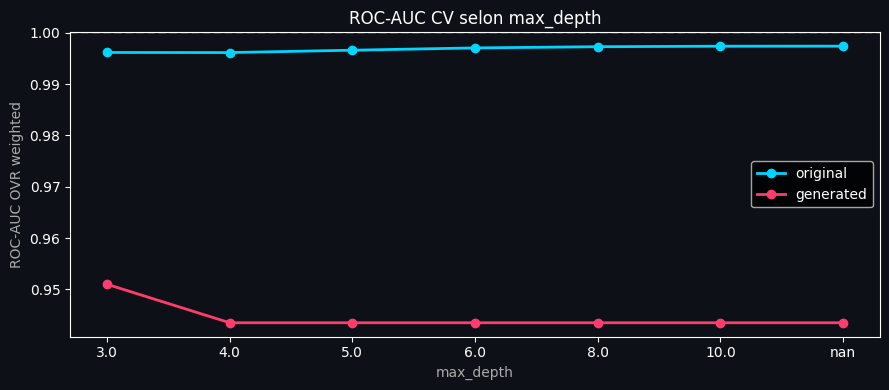

In [31]:
depths = [3, 4, 5, 6, 8, 10, None]
results_depth = {}

for d in depths:
    for ipf, name in [(ipf_orig, "original"), (ipf_gen, "generated")]:
        X = ipf[FEATURES]
        y = ipf["label"]
        counts = y.value_counts()
        valid = counts[counts >= 5].index
        X, y = X[y.isin(valid)], y[y.isin(valid)]
        if y.nunique() < 2:
            continue
        rf = RandomForestClassifier(n_estimators=100, max_depth=d, min_samples_leaf=3,
                                    class_weight="balanced", random_state=42, n_jobs=-1)
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        cv = cross_val_score(rf, X, y, cv=skf, scoring="roc_auc_ovr_weighted", n_jobs=-1)
        results_depth[(d, name)] = cv.mean()

# Affichage
import pandas as pd
df_depth = pd.DataFrame(
    [(d, name, score) for (d, name), score in results_depth.items()],
    columns=["max_depth", "dataset", "roc_auc_cv"]
)
print(df_depth.pivot(index="max_depth", columns="dataset", values="roc_auc_cv").to_string())

fig, ax = plt.subplots(figsize=(9, 4))
for name, color in [("original", "#00d4ff"), ("generated", "#ff3c6e")]:
    sub = df_depth[df_depth["dataset"] == name].sort_values("max_depth")
    labels = [str(d) if d is not None else "None" for d in sub["max_depth"]]
    ax.plot(labels, sub["roc_auc_cv"], marker="o", color=color, label=name, lw=2)
ax.set_title("ROC-AUC CV selon max_depth", color="white")
ax.set_xlabel("max_depth", color="#aaa")
ax.set_ylabel("ROC-AUC OVR weighted", color="#aaa")
ax.legend()
ax.set_facecolor("#0d1117")
ax.tick_params(colors="white")
ax.axhline(y=1.0, color="#ff3c6e", linestyle="--", alpha=0.3, label="AUC=1 (suspecte)")
fig.patch.set_facecolor("#0d1117")
plt.tight_layout()
plt.show()

## 11. Conclusion et paramètres à intégrer dans l'app

**Résumé des choix :**

| Paramètre | Valeur choisie | Justification |
|-----------|---------------|---------------|
| `n_estimators` | 100 | Compromis vitesse/performance |
| `max_depth` | Voir graphique ci-dessus | Choisir le coude de la courbe |
| `min_samples_leaf` | 3 | Évite l'overfitting sur classes rares |
| `class_weight` | `balanced` | Compense le déséquilibre Normal >> autres |
| Métrique CV | `roc_auc_ovr_weighted` | Multi-classe, robuste au déséquilibre |
| Labels | `Scanner`, `Flood`, `Brute-Force`, `Normal` | Règles métier différentes des features RF |

In [32]:
# Cellule de résumé à compléter après exécution
print("Résultats finaux à reporter dans l'app :")
print()
for name, res in [("original_data", res_orig), ("generated_data", res_gen)]:
    if res is None:
        print(f"{name}: pas de résultat")
        continue
    cv_mean = res["cv"].mean()
    cv_std  = res["cv"].std()
    classes = list(res["classes"])
    top_feat = res["imp_df"].iloc[0]["feature"]
    print(f"{name}:")
    print(f"  ROC-AUC CV : {cv_mean:.4f} ± {cv_std:.4f}")
    print(f"  Classes    : {classes}")
    print(f"  Top feature: {top_feat}")
    print()

Résultats finaux à reporter dans l'app :

original_data:
  ROC-AUC CV : 0.9970 ± 0.0003
  Classes    : ['Brute-Force', 'Normal', 'Scanner']
  Top feature: entropy_ports

generated_data:
  ROC-AUC CV : 0.9435 ± 0.0661
  Classes    : ['Brute-Force', 'Normal', 'Scanner']
  Top feature: top_port_ratio

